In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

from src.db_utils import load_sql
from src.text_preprocessing import preprocess_text

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Модули импортированы")

Модули импортированы


In [ ]:
df = load_sql("SELECT * FROM documents")
print(f"Загружено отзывов: {len(df)}")
print(f"Категории:\n{df['category'].value_counts()}")

df.head(3)

Загружено отзывов: 131669
Категории:
category
pos    87138
neu    24704
neg    19827
Name: count, dtype: int64


,id,text,category,filename,created_at
0,1,В 2003-ем году под руководством малоизвестного...,neg,1000083-0.txt,2026-07-21 14:26:39.445393
1,2,"Грустно и печально. Грустно от того, что довол...",neg,1000083-1.txt,2026-07-21 14:26:39.445393
2,3,Давным-давно Кира Найтли ворвалась на экран от...,neg,1000125-3.txt,2026-07-21 14:26:39.445393


In [4]:
df['clean_text'] = df['text'].apply(preprocess_text)

print("Пример обработанного текста:")
print(f"\nИсходный:\n{df['text'].iloc[0][:200]}...")
print(f"\nОбработанный:\n{df['clean_text'].iloc[0][:200]}...")

Пример обработанного текста:

Исходный:
В 2003-ем году под руководством малоизвестного режиссёра Кларка Джонсона студия 'Columbia Pictures' решилась на полнометражную экранизацию сериала 'Спецназ' (в оригинале 'S.W.A.T.) с Сэмюелем Л. Джекс...

Обработанный:
ем году под руководством малоизвестного режиссёра кларка джонсона студия columbia pictures решилась полнометражную экранизацию сериала спецназ оригинале s w a t сэмюелем л джексоном колином фарреллом ...


In [6]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df['clean_text'])

print(f" Размер матрицы: {X.shape}")
print(f"  - строк (отзывов): {X.shape[0]}")
print(f"  - столбцов (уникальных слов): {X.shape[1]}")
print(f"\n Тип матрицы: {type(X)}")

print(f"Ненулевых элементов: {X.nnz}")
print(f"Всего элементов: {X.shape[0] * X.shape[1]}")
print(f"Плотность: {X.nnz / (X.shape[0] * X.shape[1]) * 100:.2f}%")

 Размер матрицы: (131669, 10000)
  - строк (отзывов): 131669
  - столбцов (уникальных слов): 10000

 Тип матрицы: <class 'scipy.sparse._csr.csr_matrix'>
Ненулевых элементов: 19102017
Всего элементов: 1316690000
Плотность: 1.45%


In [ ]:
X_dense = X[:5].toarray()

feature_names = vectorizer.get_feature_names_out()

print(f"Словарь (первые 20 слов): {list(feature_names[:20])}")
print(f"\nВектор первого отзыва (первые 20 значений):")
print(X_dense[0, :10])

nonzero_indices = X[0].nonzero()[1]
print(f"\nСлова с ненулевыми TF-IDF в первом отзыве:")
for idx in nonzero_indices[:10]:
    word = feature_names[idx]
    weight = X[0, idx]
    print(f"  {word}: {weight:.4f}")

Словарь (первые 20 слов): ['and', 'dc', 'disney', 'dvd', 'ii', 'in', 'is', 'it', 'la', 'love', 'marvel', 'me', 'movie', 'my', 'netflix', 'no', 'of', 'on', 'pixar', 'ps']

Вектор первого отзыва (первые 20 значений):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Слова с ненулевыми TF-IDF в первом отзыве:
  году: 0.0938
  под: 0.0323
  руководством: 0.0824
  режиссёра: 0.0561
  джонсона: 0.0871
  студия: 0.0774
  решилась: 0.0871
  экранизацию: 0.0709
  сериала: 0.0489
  оригинале: 0.0694


In [40]:
idf_values = vectorizer.idf_

idf_df = pd.DataFrame({
    'word': feature_names,
    'idf': idf_values
})

idf_df = idf_df.sort_values('idf', ascending=False)

print("Топ-20 самых редких слов (высокий IDF):")
print(idf_df.head(20))

print("\nТоп-20 самых частых слов (низкий IDF):")
print(idf_df.tail(20))

Топ-20 самых редких слов (высокий IDF):
          word       idf
7412   сальери  8.124615
216        аче  7.943867
9844      эдит  7.706650
7325   розмари  7.676066
218       баби  7.670060
2142    жасмин  7.664090
244      баффи  7.658155
4083   моцарта  7.634762
1384  годзилла  7.562307
1755     джобс  7.556945
9443    хатико  7.525364
6898     пуаро  7.515055
7274     рипли  7.489737
2978       кар  7.474848
570   вачовски  7.460178
1756    джобса  7.455335
7409   сайлент  7.450516
4174       мэй  7.445720
4177   мэрилин  7.426762
8877      точь  7.422078

Топ-20 самых частых слов (низкий IDF):
         word       idf
7537     себя  2.140132
8836     того  2.127225
1025    время  2.112608
3299  которые  2.093182
3066     кино  2.088705
9643      чем  2.046756
4008    может  2.031407
9927    этого  2.013043
9354   фильме  1.981138
9929     этом  1.957474
3300  который  1.928594
2911       их  1.918838
5027      они  1.899646
1827       до  1.898787
2119     есть  1.891389
4011    мож

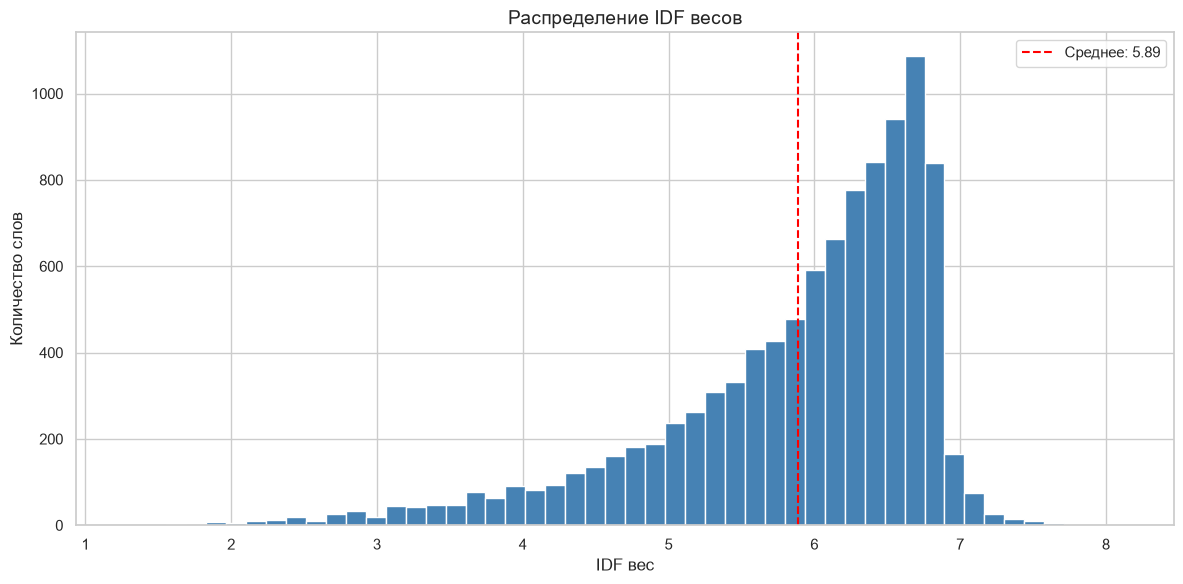

In [ ]:
fig, ax = plt.subplots()

ax.hist(idf_values, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Распределение IDF весов', fontsize=14)
ax.set_xlabel('IDF вес')
ax.set_ylabel('Количество слов')
ax.axvline(idf_values.mean(), color='red', linestyle='--', 
           label=f'Среднее: {idf_values.mean():.2f}')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/idf_distribution.png', dpi=150)
plt.show()

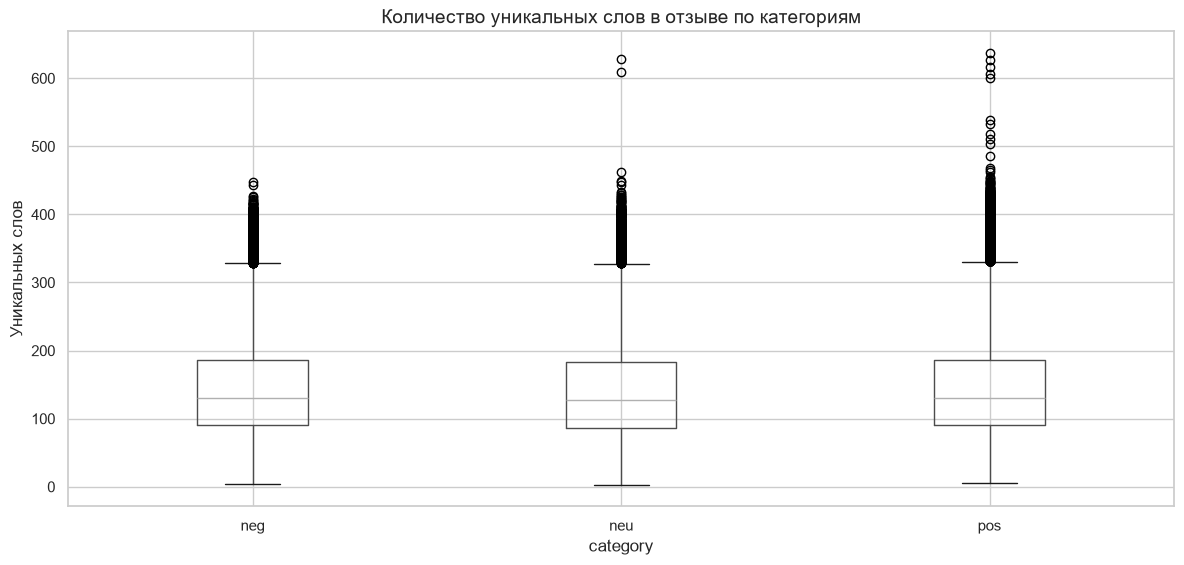


📏 Статистика по количеству уникальных слов:
            count        mean        std  min   25%    50%    75%    max
category                                                                
neg       19827.0  145.966056  74.665900  4.0  91.0  131.0  186.0  447.0
neu       24704.0  141.800640  75.665719  3.0  87.0  128.0  183.0  628.0
pos       87138.0  145.802118  76.668864  5.0  90.0  130.0  186.0  637.0


In [ ]:
df['num_words'] = [X[i].nnz for i in range(X.shape[0])]

fig, ax = plt.subplots()

df.boxplot(column='num_words', by='category', ax=ax)
plt.suptitle('')
plt.title('Количество уникальных слов в отзыве по категориям', fontsize=14)
plt.ylabel('Уникальных слов')
plt.tight_layout()
plt.savefig('../data/processed/words_per_category.png', dpi=150)
plt.show()

print("\nСтатистика по количеству уникальных слов:")
print(df.groupby('category')['num_words'].describe())

In [38]:
pos_reviews = df[df['category'] == 'pos'].index[:2]

vec1 = X[pos_reviews[0]].toarray().flatten()
vec2 = X[pos_reviews[1]].toarray().flatten()

from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity([vec1], [vec2])

print(f"\nКосинусное сходство: {similarity[0][0]}")


Косинусное сходство: 0.040135682738267876


In [ ]:
joblib.dump(vectorizer, '../models/tfidf_vectorizer_v1.pkl')
print("Векторизатор сохранён: models/tfidf_vectorizer_v1.pkl")

df.to_csv('../data/processed/reviews_with_tfidf.csv', index=False)
print("Данные сохранены: data/processed/reviews_with_tfidf.csv")

Векторизатор сохранён: models/tfidf_vectorizer_v1.pkl
Данные сохранены: data/processed/reviews_with_tfidf.csv
